# Notebook 01 — Business & Data Understanding

**Projet : ImmoAsk IA** — Système de recommandation immobilière
**Phase CRISP-DM : 1 et 2 sur 6**
**Équipe de 4** — Rôle : Data / Analyse

---

## 1. Business Understanding (phase 1 CRISP-DM)

### 1.1 Contexte métier
Le marché immobilier togolais s'appuie fortement sur des plateformes hétérogènes (Facebook Marketplace, CoinAfrique, sites spécialisés ImmoAsk, etc.) rendant la recherche d'un bien adapté très chronophage pour l'utilisateur. Les annonces sont rédigées dans un langage libre, avec peu de standardisation (type de bien, quartier, nombre de pièces, prix).

### 1.2 Problème à résoudre
> **À partir d'une annonce de référence (ou d'une requête utilisateur), proposer automatiquement les `k` annonces les plus pertinentes du catalogue.**

### 1.3 Objectifs business
1. Réduire le temps de recherche d'un bien de 70% (proxy : nombre d'annonces à scroller).
2. Augmenter la qualité des suggestions (pertinence > 95%).
3. Proposer une API réutilisable pour intégration dans un front-end web/mobile.

### 1.4 KPIs retenus

| KPI | Cible | Justification |
|---|---|---|
| **Precision@5** | ≥ 95% | Les 5 annonces suggérées doivent correspondre au besoin (même ville + même type de bien) |
| **Recall@5** | ≥ 85% | Le modèle ne doit pas rater les biens similaires du catalogue |
| **F1-Score** | ≥ 90% | Équilibre précision/rappel |
| **Latence** | < 100 ms | Usage interactif |

### 1.5 Approche choisie
**Content-Based Filtering (TF-IDF + similarité cosinus)**

Justification :
- Pas de données utilisateurs (pas de clics, pas de notes) → filtrage collaboratif impossible.
- Les titres et descriptions contiennent beaucoup d'information textuelle exploitable.
- TF-IDF est interprétable, rapide, déterministe et ne nécessite pas de GPU.

---

## 2. Data Understanding (phase 2 CRISP-DM)

In [1]:
# Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

In [2]:
# Chargement des données
DATA_PATH = "../data/processed/annonces_immobilier.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
df.head(3)

Shape : (255, 10)


,id,document,metadata,titre,prix,ville,source,lien,image_url,date_migration
0,fb_69a97f6185f1dd70f9aef290,Titre: CHAMBRE SALON NOUVELLE CONSTRUCTION À L...,"{""lien"": ""https://www.facebook.com/marketplace...",CHAMBRE SALON NOUVELLE CONSTRUCTION À LOUER À ...,35000.0,Togo,Facebook,https://www.facebook.com/marketplace/item/9123...,https://scontent-cph2-1.xx.fbcdn.net/v/t39.308...,2026-03-05 15:01:50.908205
1,fb_69a97f6185f1dd70f9aef291,Titre: A louer Chambre salon wc douche ( SANGU...,"{""lien"": ""https://www.facebook.com/marketplace...",A louer Chambre salon wc douche ( SANGUERA KLI...,40000.0,Togo,Facebook,https://www.facebook.com/marketplace/item/2684...,https://scontent-cph2-1.xx.fbcdn.net/v/t39.847...,2026-03-05 15:01:50.908205
2,fb_69a97f6185f1dd70f9aef292,Titre: A louer deux chambre salon agoè daliko....,"{""lien"": ""https://www.facebook.com/marketplace...",A louer deux chambre salon agoè daliko,40000.0,Togo,Facebook,https://www.facebook.com/marketplace/item/9504...,https://scontent-cph2-1.xx.fbcdn.net/v/t39.847...,2026-03-05 15:01:50.908205


### 2.1 Schéma et typage

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              255 non-null    object 
 1   document        255 non-null    object 
 2   metadata        255 non-null    object 
 3   titre           252 non-null    object 
 4   prix            255 non-null    float64
 5   ville           255 non-null    object 
 6   source          255 non-null    object 
 7   lien            255 non-null    object 
 8   image_url       202 non-null    object 
 9   date_migration  255 non-null    object 
dtypes: float64(1), object(9)
memory usage: 20.0+ KB


### 2.2 Valeurs manquantes

In [4]:
nulls = df.isna().sum().to_frame("n_manquants")
nulls["pct"] = (nulls["n_manquants"] / len(df) * 100).round(2)
nulls.sort_values("n_manquants", ascending=False)

,n_manquants,pct
image_url,53,20.78
titre,3,1.18
document,0,0.00
id,0,0.00
prix,0,0.00
metadata,0,0.00
ville,0,0.00
source,0,0.00
lien,0,0.00
date_migration,0,0.00


**Observations :**
- `image_url` : ~20% de valeurs manquantes → acceptable, non utilisé pour la modélisation.
- `titre` : 3 valeurs manquantes → à traiter (suppression ou imputation depuis `document`).

### 2.3 Distribution des sources et villes

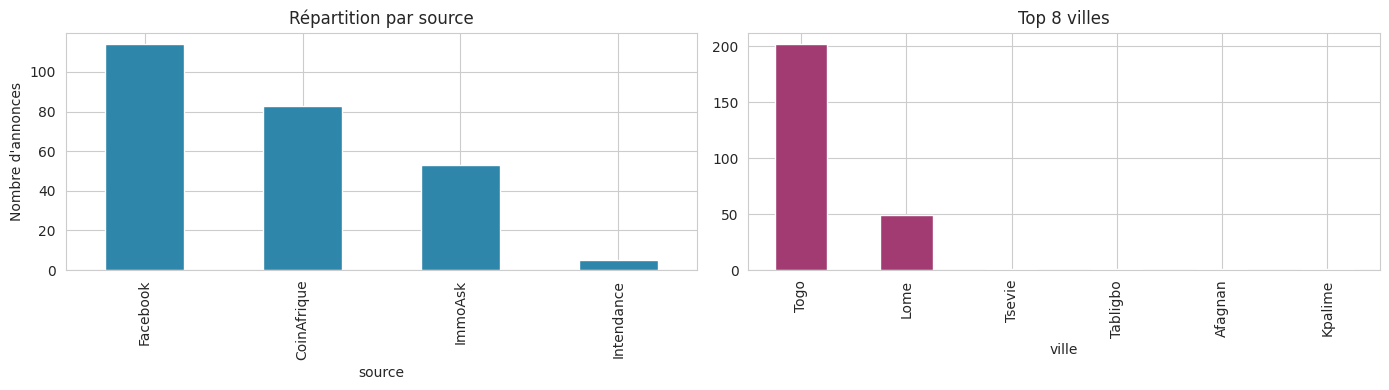

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["source"].value_counts().plot(kind="bar", ax=axes[0], color="#2E86AB")
axes[0].set_title("Répartition par source")
axes[0].set_ylabel("Nombre d'annonces")

df["ville"].value_counts().head(8).plot(kind="bar", ax=axes[1], color="#A23B72")
axes[1].set_title("Top 8 villes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Observations :**
- Forte prédominance de Facebook (~45%) et CoinAfrique (~33%).
- La colonne `ville` est peu informative : ~79% des annonces sont taguées "Togo" (valeur générique).
- Il faudra **ré-extraire la ville réelle** à partir du titre (Lomé, Agoè, Kégué, etc.) lors de la Data Preparation.

### 2.4 Distribution des prix

Stats descriptives - prix (CFA) :
count    2.550000e+02
mean     2.939544e+07
std      9.576921e+07
min      0.000000e+00
25%      8.500000e+00
50%      4.000000e+04
75%      1.700000e+07
max      8.500000e+08
Name: prix, dtype: float64


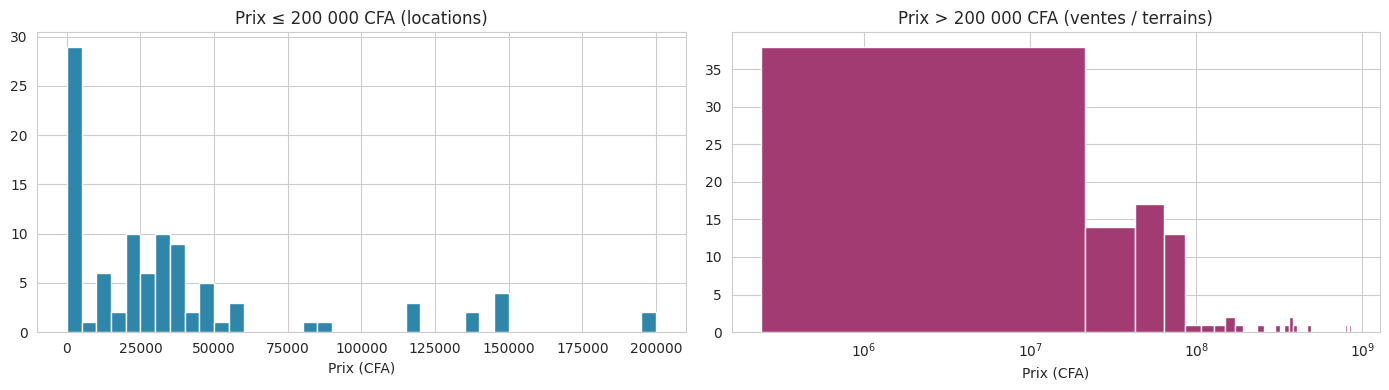

In [6]:
print("Stats descriptives - prix (CFA) :")
print(df["prix"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
locations = df.loc[(df["prix"] > 0) & (df["prix"] <= 200_000), "prix"]
ventes = df.loc[df["prix"] > 200_000, "prix"]

locations.hist(bins=40, ax=axes[0], color="#2E86AB", edgecolor="white")
axes[0].set_title("Prix ≤ 200 000 CFA (locations)")
axes[0].set_xlabel("Prix (CFA)")

ventes.hist(bins=40, ax=axes[1], color="#A23B72", edgecolor="white")
axes[1].set_title("Prix > 200 000 CFA (ventes / terrains)")
axes[1].set_xlabel("Prix (CFA)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

**Observations :**
- Le dataset mélange **locations** (< 200 000 CFA/mois) et **ventes / terrains** (> 1 M CFA).
- Les prix à **0 CFA** (annonces sans prix affiché) sont des anomalies à exclure des analyses statistiques.
- Les prix < 100 CFA sont également aberrants (bug de scraping probable).

On introduira donc une variable catégorielle `type_transaction` ∈ {location, vente, terrain, autre} en phase 2 de préparation.

### 2.5 Analyse textuelle des titres

In [7]:
df["titre_len"] = df["titre"].fillna("").str.len()
df["titre_words"] = df["titre"].fillna("").str.split().str.len()

print("Longueur des titres (caractères) :")
print(df["titre_len"].describe().round(1))
print("\nNombre de mots par titre :")
print(df["titre_words"].describe().round(1))

Longueur des titres (caractères) :
count    255.0
mean      38.9
std       21.0
min        0.0
25%       27.0
50%       34.0
75%       46.5
max      100.0
Name: titre_len, dtype: float64

Nombre de mots par titre :
count    255.0
mean       6.0
std        4.1
min        0.0
25%        2.0
50%        6.0
75%        8.0
max       19.0
Name: titre_words, dtype: float64


In [8]:
# Mots les plus fréquents dans les titres
from collections import Counter
import re

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\sàâäçéèêëîïôöùûüÿñœ]", " ", text)
    return [t for t in text.split() if len(t) > 2]

all_tokens = [t for title in df["titre"].dropna() for t in tokenize(title)]
top_words = Counter(all_tokens).most_common(20)
print("Top 20 mots-clés dans les titres :")
for w, c in top_words:
    print(f"  {w:20s} {c}")

Top 20 mots-clés dans les titres :
  salon                80
  terrain              75
  louer                63
  villa                60
  chambre              58
  lome                 46
  appartement          40
  vendre               35
  interne              34
  meublé               32
  lot                  29
  cuisine              24
  chambres             24
  vente                23
  lots                 19
  agoe                 18
  lomé                 18
  douche               16
  pièces               16
  wcd                  14


**Observations :**
- Titres courts (~50 caractères, 7-8 mots en moyenne).
- Les mots-clés dominants sont typiques de la recommandation : **chambre**, **salon**, **louer**, **vendre**, **terrain**, **lomé**, **maison**, **appartement**.
- Le **vocabulaire métier est relativement restreint** → TF-IDF sera très efficace.

### 2.6 Détection d'anomalies

In [9]:
anomalies = {
    "prix_zero": (df["prix"] == 0).sum(),
    "prix_suspect_trop_bas": ((df["prix"] > 0) & (df["prix"] < 100)).sum(),
    "titre_null": df["titre"].isna().sum(),
    "titre_trop_court": (df["titre"].fillna("").str.len() < 10).sum(),
    "doublons_id": df["id"].duplicated().sum(),
    "doublons_titre_prix": df.duplicated(subset=["titre", "prix", "ville"]).sum(),
}
pd.Series(anomalies, name="n").to_frame()

,n
prix_zero,61
prix_suspect_trop_bas,17
titre_null,3
titre_trop_court,9
doublons_id,0
doublons_titre_prix,0


**Observations clés à transmettre à la phase de Data Preparation :**
1. Supprimer les annonces à **prix = 0** et les prix **< 100 CFA** (probables erreurs de scraping).
2. Ré-extraire la ville réelle depuis le titre (regex sur Lomé, Agoè, Tsévié, etc.).
3. Ajouter une colonne `type_transaction` (location / vente / terrain / autre).
4. Ajouter une colonne `type_bien` (chambre-salon / appartement / maison / terrain / villa).
5. Supprimer les 3 titres nuls (ou les remplacer par le début du `document`).
6. Normaliser la casse et enlever les caractères spéciaux pour le TF-IDF.

### 2.7 Conclusion — livrables de la phase Data Understanding
- **Volume** : 255 annonces → suffisant pour une démonstration content-based.
- **Qualité** : correcte, mais la colonne `ville` doit être retraitée.
- **Potentiel** : fort — les titres sont concis et lexicalement riches.
- **Risques identifiés** : déséquilibre location/vente, qualité variable entre sources.

➡️ Passage à la phase 3 : **Data Preparation** (notebook 02).